# Add in the data from the extra datasets

Make the metadata file, this we need to do by reading in each of the files and taking the first row. 

### Metadata rows.
```
experiment_id	experiment_name	experiment_date	substrate_smiles	product_smiles	assay_technique	parent_amino_acid	cif_filename

```

## Parents are:

```
PfTrpB-xxx  I165_I183_Y301
ParLQ-x     W56_Y57_L59_Q60_F89
Rma-x       V75V_M99M_M100M_T101T_D102D_M103M --> 
```

In [1]:
import pandas as pd
import os
# First alter the files to have a parent in the first row
data_dir = 'DEDB/new-ds-yl/processed/'
files = os.listdir(data_dir)

columns = ['experiment_id', 'experiment_name', 'experiment_date', 
           'substrate_smiles', 'product_smiles', 'assay_technique', 
           'parent_amino_acid', 'cif_filename']


In [2]:
rows = []
all_df = pd.DataFrame()
for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')    
        # Also copy accross the structure
        name = ''
        if 'PfTrpB' in f:
            name = f.replace('PfTrpB-', '').replace('_processed.csv', '')
            name = name[0] + '-' + name[1:]
            experiment_name = f'PfTrpB_{name}'
        else:
            name = f.replace('_processed.csv', '')
            experiment_name = name
    
        if 'ParLQ' in f:
            df['amino_acid_substitutions'] = [a if a != 'W56W_Y57Y_L59L_Q60Q_F89F' else '#PARENT#' for a in df['amino_acid_substitutions'].values]
        elif 'PfTrpB' in f:
            df['amino_acid_substitutions'] = [a if a != 'I165I_I183I_Y301Y' else '#PARENT#' for a in df['amino_acid_substitutions'].values]
        elif 'Rma' in f:
            df['amino_acid_substitutions'] = [a if a != 'V75V_M99M_M100M_T101T_D102D_M103M' else '#PARENT#' for a in df['amino_acid_substitutions'].values]
            # This one is missing the parent so we have to infer it and then create a dummy row
            parent_aa = list(df['aa_sequence'].values[0])
            # Revert back the mutations
            aa_subs = df['amino_acid_substitutions'].values[0]
            for a in aa_subs.split('_'):
                pos = int(a[1:-1]) - 1 # Since usually 1 indexed
                parent_aa[pos] = a[0]
            parent_aa = ''.join(parent_aa)
        
            # Append a final row on
            plate_id = max(df['plate'].values)
            df['barcode_plate'] = df['plate'].values
            row = list(df.values[0])
            row[4] = '#PARENT#' #	1	0	0	0	0	ATGGCTGTTCCTGGTTATGATTTTGGTAAAGTTCCTGATGCTCCTATTTCTGATGCTGATTTTGAATCTCTTAAAAAAACTGTTATGTGGGGTGAAGAAGATGAAAAATATCGTAAAATGGCTTGTGAAGCTCTTAAAGGTCAAGTTGAAGATATTCTTGATCTTGCTTATGGTCTTCAAGGTTCTAATCAACATCTTATTTATTATTTTGGTGATAAATCTGGTCGTCCTATTCCTCAATATCTTGAAGCTGTTCGTAAACGTTTTGGTCTTTGGATTATTGATACTCTTTGTAAACCTCTTGATCGTCAATGGCTTAATTATATGTATGAAATTGGTCTTCGTCATCATCGTACTAAAAAAGGTAAAACTGATGGTGTTGATACTGTTGAACATATTCCTCTTCGTTATATGATTGCTTTTATTGCTCCTATTGGTCTTACTATTAAACCTATTCTTGAAAAATCTGGTCATCCTCCTGAAGCTGTTGAACGTATGTGGGCTGCTTGGGTTAAACTTGTTGTTCTTCAAGTTGCTATTTGGTCTTATCCTTATGCTAAAACTGGTGAATGG	MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALKGQVEDILDLAYGLQGSNQHLIYYFGDKSGRPIPQYLEAVRKRFGLWIIDTLCKPLDRQWLNYMYEIGLRHHRTKKGKTDGVDTVEHIPLRYMIAFIAPIGLTIKPILEKSGHPPEAVERMWAAWVKLVVLQVAIWSYPYAKTGEW	C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-]>>COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3	0.679908496	selectivity: 0.066311735]
            row[1] = plate_id + 1
            row[2] = plate_id + 1
            row[11] = parent_aa
            row[10] = None
            row[13] = 1
            row_df = pd.DataFrame([row], columns=df.columns)
            df = pd.concat([df, row_df])
        else:
            df['amino_acid_substitutions'] = [a if a != 'WT' else '#PARENT#' for a in df['amino_acid_substitutions'].values]
            
        parents = df[df['amino_acid_substitutions'] == '#PARENT#']
        
        parent_aa = str(parents['aa_sequence'].values[0])
        structure = f'DEDB/new-ds-yl/structure/{name}/{name}.cif'
        if os.path.exists(structure):
            os.system(f'cp {structure} DEDB/new-ds-yl/reformatted/structures/{experiment_name}.cif')
            
            rxn = df['smiles_string'].values[0]
            product = rxn.split('>>')[-1]
            substrates = rxn.split('>>')[0]
            df['smiles_string'] = product
            df['reaction_string'] = rxn
            
            row = [experiment_name, experiment_name, None, substrates, product, None, parent_aa, f'{experiment_name}.cif']
            df.to_csv(f'DEDB/new-ds-yl/reformatted/{experiment_name}.csv', index=False)
            rows.append(row)
            all_df = pd.concat([df, all_df])
    except:
        print(f)
        
meta_df = pd.DataFrame(rows)
meta_df.columns = columns
meta_df


sample.csv


,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename
0,PfTrpB_7-methyl,PfTrpB_7-methyl,None,CC1=CC=CC2=C1NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC=C4C)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_7-methyl.cif
1,ParLQ-h,ParLQ-h,None,C=CC1=CC=C(C(F)(F)F)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(C(F)(F)F)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-h.cif
2,PfTrpB_5-iodo,PfTrpB_5-iodo,None,IC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(I)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-iodo.cif
3,PfTrpB_5-chloro,PfTrpB_5-chloro,None,ClC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(Cl)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-chloro.cif
4,PfTrpB_4-bromo,PfTrpB_4-bromo,None,BrC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(Br)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-bromo.cif
5,PfTrpB_4-cyano,PfTrpB_4-cyano,None,N#CC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(C#N)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-cyano.cif
6,ParLQ-b,ParLQ-b,None,C=CC1=CC=CC=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=CC=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-b.cif
7,PfTrpB_6-chloro,PfTrpB_6-chloro,None,ClC1=CC2=C(C=CN2)C=C1.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC(Cl)=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_6-chloro.cif
8,ParLQ-f,ParLQ-f,None,C=CC1=CC=C(Cl)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(Cl)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-f.cif
9,ParLQ-a,ParLQ-a,None,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-a.cif


In [3]:
meta_df.to_csv('DEDB/new-ds-yl/reformatted/meta_data_new_collections.csv', index=False)

# Draw some graphs for the reviewer to show the distribution of fitness values


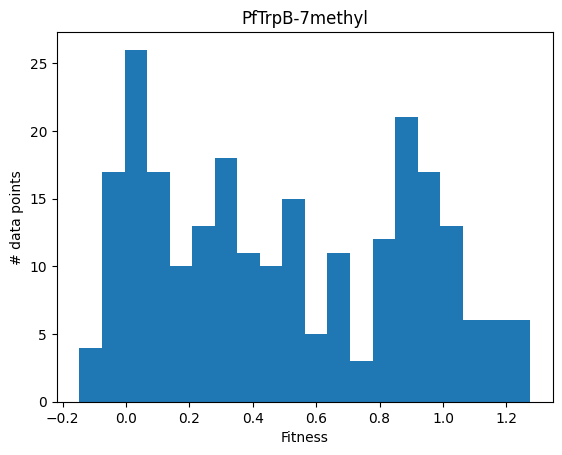

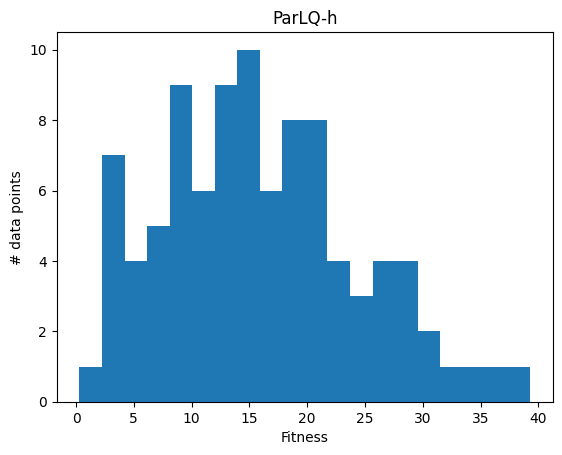

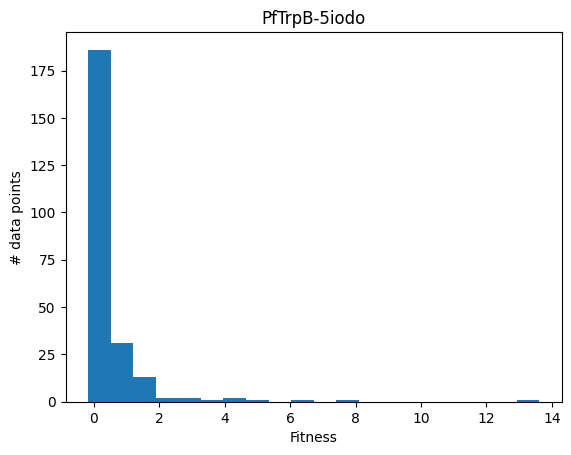

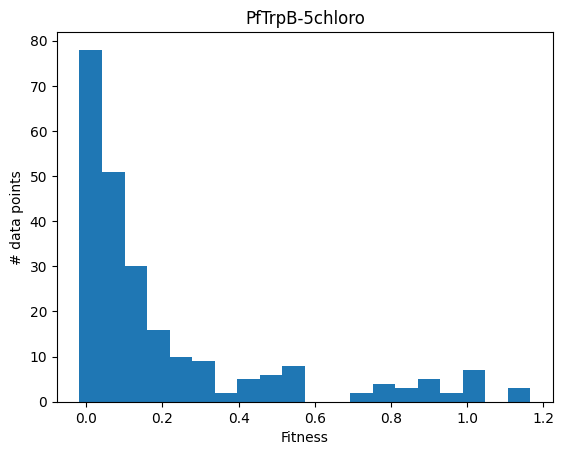

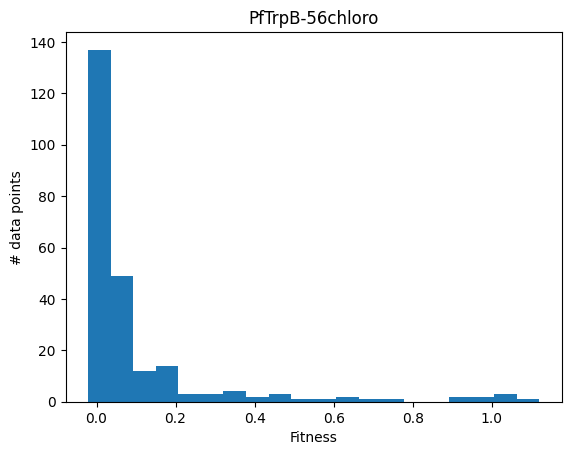

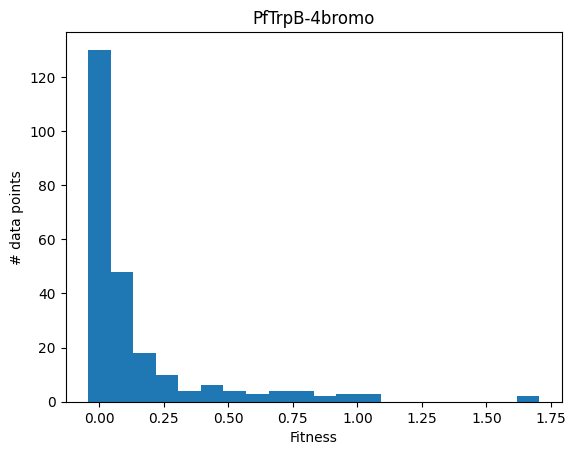

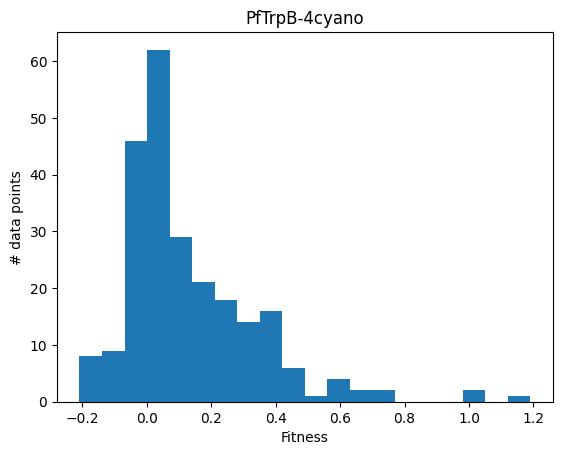

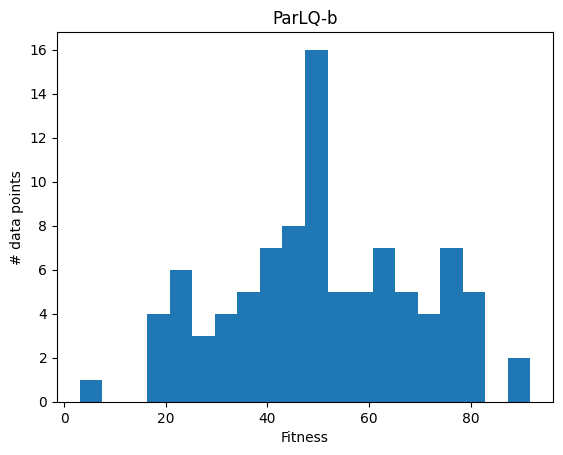

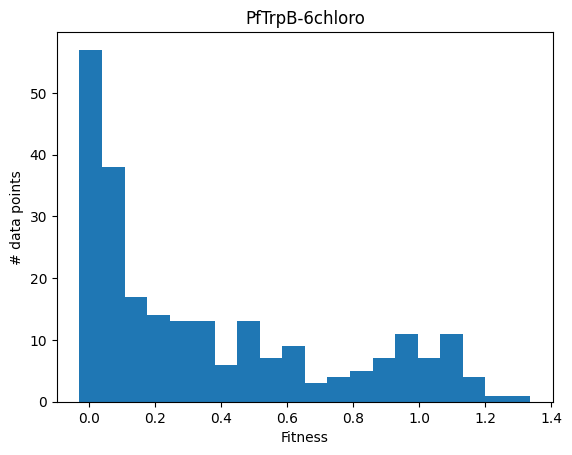

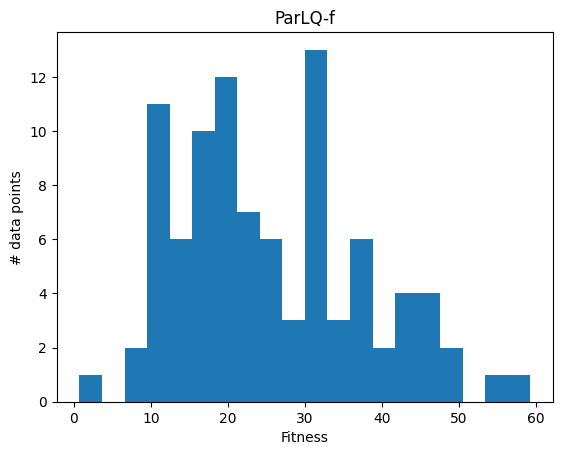

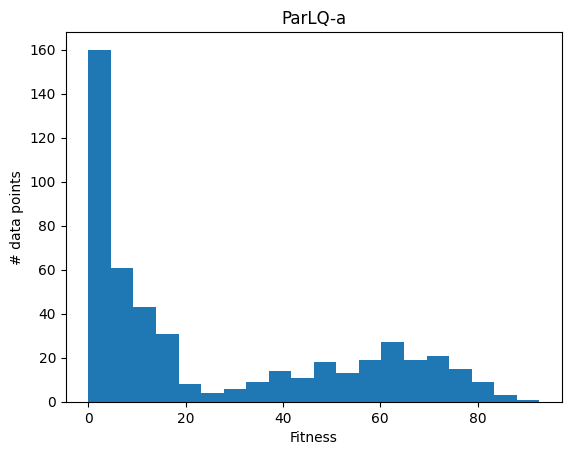

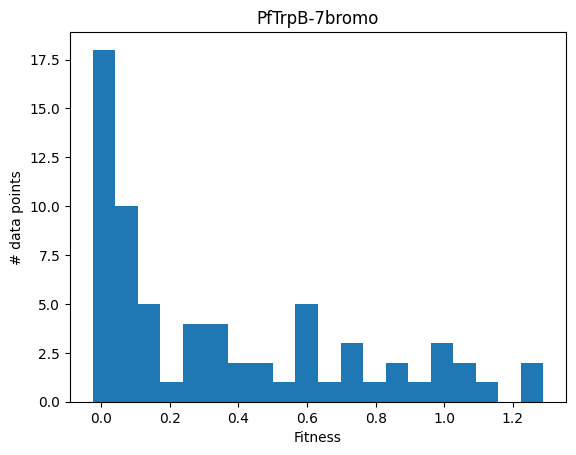

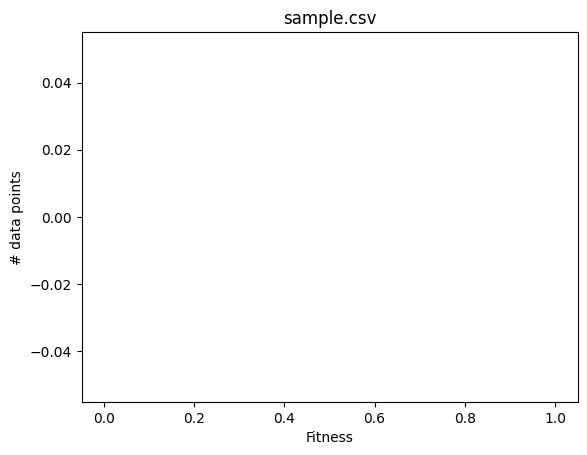

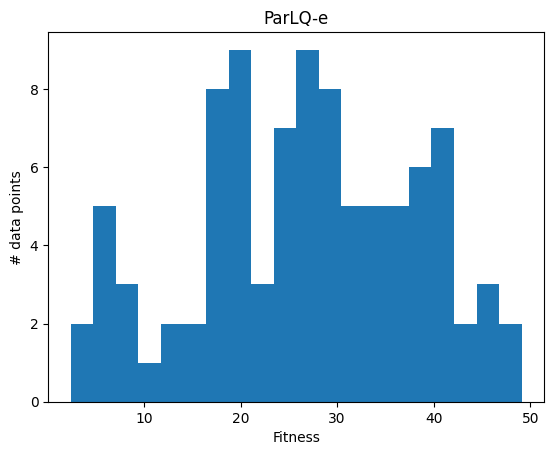

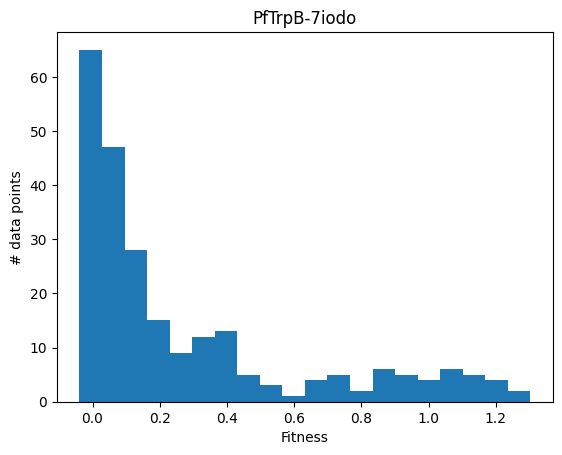

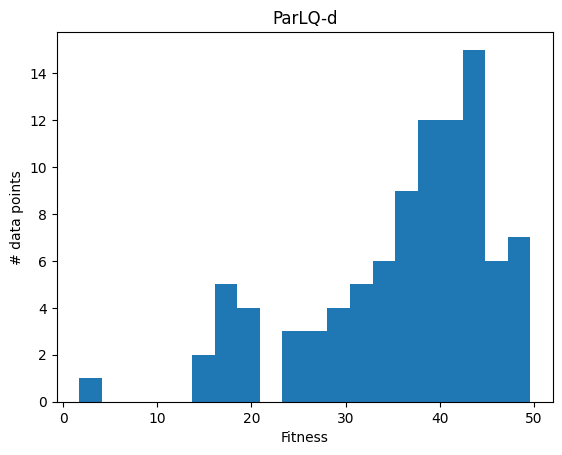

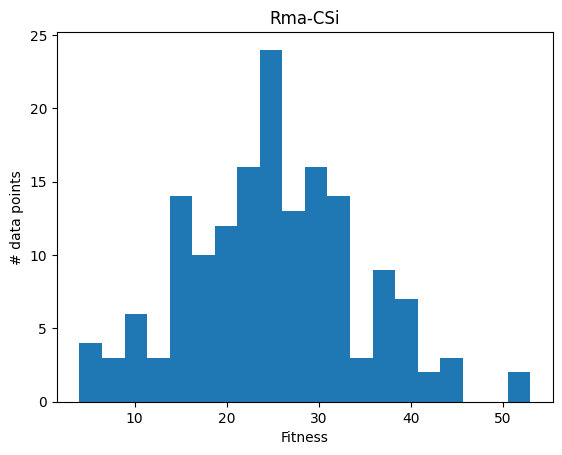

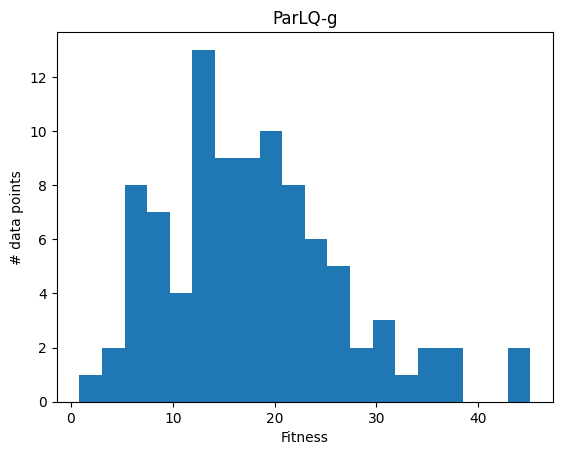

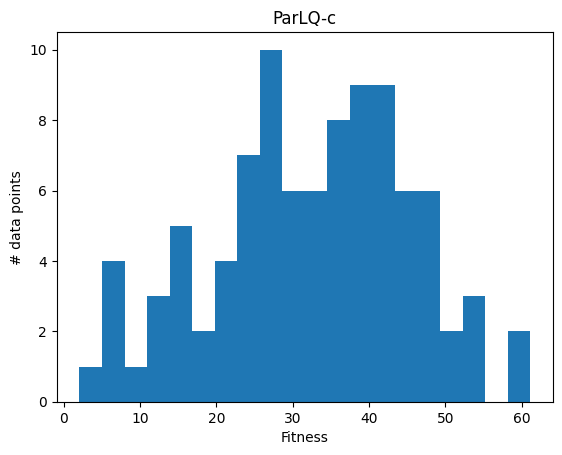

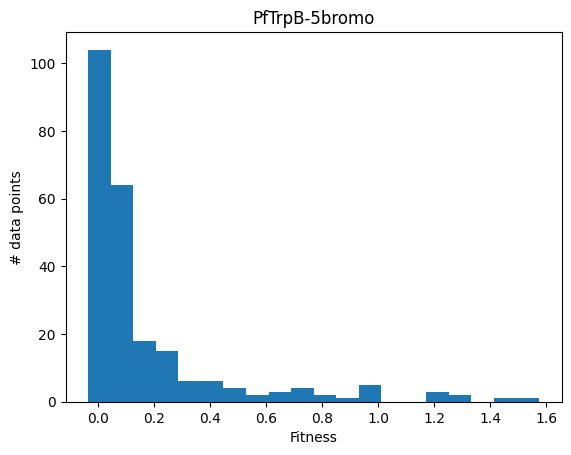

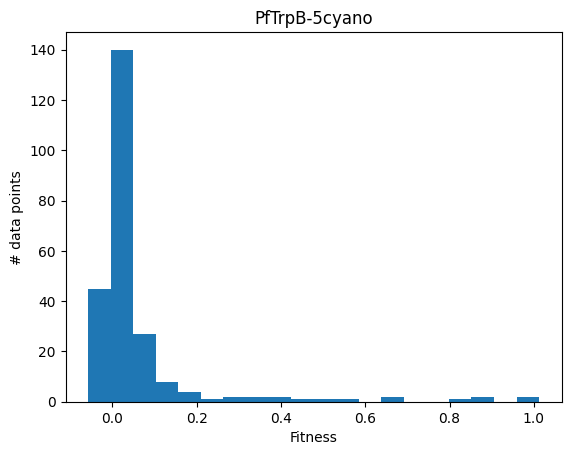

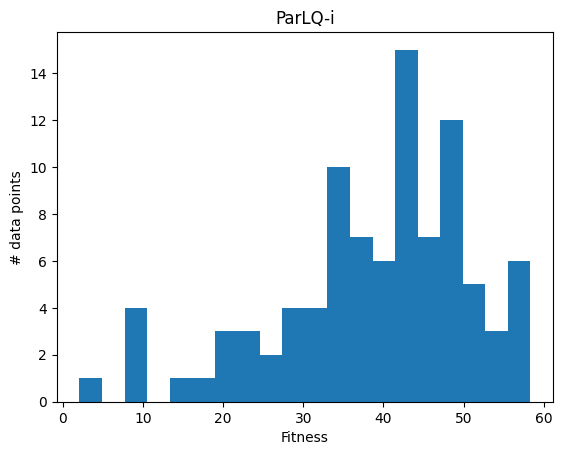

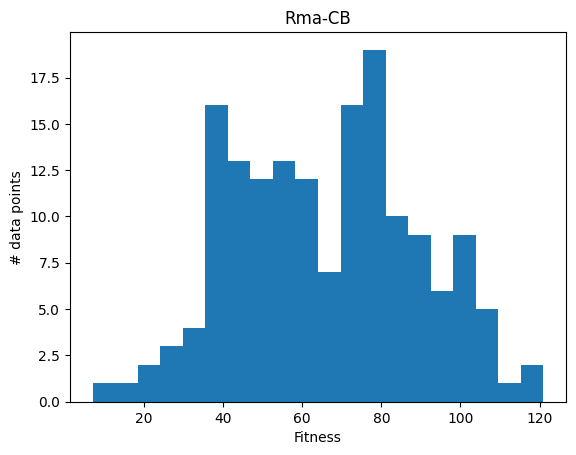

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')
        plt.hist(df['fitness_value'].values, bins=20)
        plt.title(f.replace('_processed.csv', ''))
        plt.xlabel('Fitness')
        plt.ylabel('# data points')
        plt.show()
    except:
        print(f)


# For francesscas there are parents which we just need to match
```
DHFR		A26_D27_L28 
T7	 	    N748_R756_Q758
TEV		    T146_D148_H167_S170
TrpB3A		A104_E105_T106
TrpB3B		E105_T106_G107
TrpB3C		T106_G107_A108
TrpB3D		T117_A118_A119
TrpB3E		F184_G185_S186
TrpB3F		L162_I166_Y301
TrpB3G		V227_S228_Y301
TrpB3H		S228_G230_S231
TrpB3I		Y182_V183_F184
TrpB4		V183_F184_V227_S228
```

These are represented by WT in the datasets.

In [5]:
import pandas as pd
import os
# First alter the files to have a parent in the first row
data_dir = 'DEDB/new-ds-fzl/processed/'
files = os.listdir(data_dir)
columns = ['experiment_id', 'experiment_name', 'experiment_date', 
           'substrate_smiles', 'product_smiles', 'assay_technique', 
           'parent_amino_acid', 'cif_filename']


In [6]:
rows = []
all_df = pd.DataFrame()
for f in files:
    #try:
    df = pd.read_csv(f'{data_dir}{f}')
    # Additionally replace R groups from the smiles string... 
    df['smiles_string'] = [s.replace('R', '*:') for s in df['smiles_string'].values]
    df['barcode_plate'] = df['plate'].values

    # Append a final row on
    plate_id = max(df['plate'].values)
    
    # Also copy accross the structure
    name = f.replace('_processed.csv', '')
    experiment_name = name
    cif_name = name
    if 'TrpB' in name:
        cif_name = name[:-2]
    # Convert the ones that have the PARENT sequence to be parents
    df['amino_acid_substitutions'] = [a if a != 'WT' else '#PARENT#' for a in df['amino_acid_substitutions'].values]
    parents = df[df['amino_acid_substitutions'] == '#PARENT#']
    parent_aa = str(parents['aa_sequence'].values[0])
    structure = f'DEDB/new-ds-fzl/structure/{cif_name}.cif'
    if os.path.exists(structure):
        os.system(f'cp {structure} DEDB/new-ds-yl/reformatted/structures/{experiment_name}.cif')
        
        rxn = df['smiles_string'].values[0]
        product = rxn.split('>>')[-1]
        substrates = rxn.split('>>')[0]
        df['smiles_string'] = product
        df['reaction_string'] = rxn
        
        row = [experiment_name, experiment_name, None, substrates, product, None,	parent_aa, f'{experiment_name}.cif']
        df.to_csv(f'DEDB/new-ds-yl/reformatted/{experiment_name}.csv', index=False)
        rows.append(row)
        all_df = pd.concat([df, all_df])
        
meta_df = pd.DataFrame(rows)
meta_df.columns = columns
meta_df


,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename
0,TrpB3H,TrpB3H,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3H.cif
1,DHFR,DHFR,None,OC([C@@H](NC(C1=CC=C(NCC2=NC3=C(NC2)N=C(N)NC3=...,OC([C@@H](NC(C9=CC=C(NCC%10NC%11=C(NC%10)N=C(N...,None,MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHT...,DHFR.cif
2,TrpB3A,TrpB3A,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3A.cif
3,TrpB3E,TrpB3E,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3E.cif
4,TrpB3B,TrpB3B,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3B.cif
5,TrpB3F,TrpB3F,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3F.cif
6,TrpB3G,TrpB3G,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3G.cif
7,TrpB3C,TrpB3C,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3C.cif
8,TrpB3D,TrpB3D,None,N[C@@H](CO)C(O)=O.C12=C(NC=C2)C=CC=C1,N[C@@H](CC3=CNC4=C3C=CC=C4)C(O)=O,None,MKGYFGPYGGQYVPEILMGALEELEAAYEGIMKDESFWKEFNDLLR...,TrpB3D.cif
9,T7,T7,None,OCC1OC(COP(O)(O)=O)(C(C1O[*:1])O)O.OCC2OC(COP(...,OCC3OC(COP(O)(OCC4OC(C(C4O[*:2])O)O)=O)(C(C3O[...,None,MNTINIAKNDFSDIELAAIPFNTLADHYGERLAREQLALEHESYEM...,T7.cif


In [7]:
meta_df.to_csv('DEDB/new-ds-yl/reformatted/meta_data_new_collections.csv', index=False)

# Check the smiles are able to be correctly parsed by RdKit

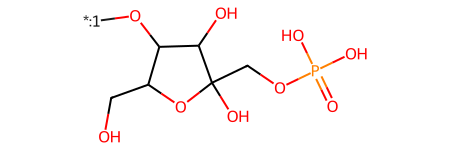

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw, rdChemReactions
smiles = 'OCC1OC(C(O)C1OC)(O)COP(O)(O)=O'
smiles = 'OCC1OC(COP(O)(O)=O)(C(C1O[*:1])O)O'
mol = Chem.MolFromSmiles(smiles)
mol

*
C
N
C
C
N
C
C
*
O
*
O
*
O
O


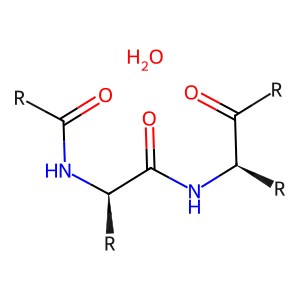

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw

# Create a benzene with an R group placeholder (* atom)
mol = Chem.MolFromSmiles("[*:1]C(N[C@@H](C(N[C@@H](C([*:2])=O)[*:3])=O)[*:4])=O.O")

# Draw with atom labels
d2d = Draw.MolDraw2DSVG(300, 300)
opts = d2d.drawOptions()

# Replace '*' with "R1" in the rendering
for i, atom in enumerate(mol.GetAtoms()):
    print(atom.GetSymbol())
    if atom.GetSymbol() == "*":
        opts.atomLabels[i] = "R"

d2d.DrawMolecule(mol)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()

# If in Jupyter/IPython you can do:
from IPython.display import SVG
SVG(svg)

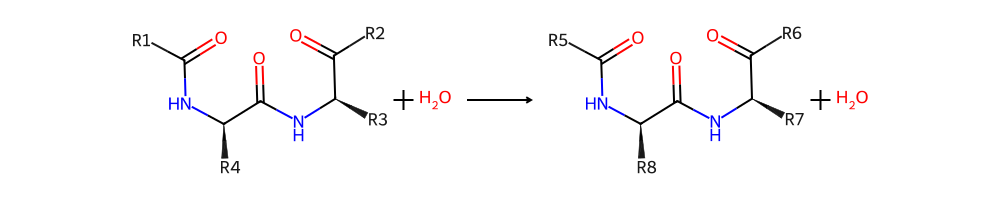

In [11]:
# Testing code before deployment
substrate_smiles = '[*]C(N[C@@H](C(N[C@@H](C([*])=O)[*])=O)[*])=O.O'
product_smiles = '[*]C(N[C@@H](C(N[C@@H](C([*])=O)[*])=O)[*])=O.O'

rxn_smarts = f"{substrate_smiles}>>{product_smiles}"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts, useSmiles=True)

ideal_final_width = 1000
w = int(ideal_final_width / (rxn.GetNumReactantTemplates() + rxn.GetNumProductTemplates() + 1))
d2d = Draw.MolDraw2DSVG(1000, 200)
opts = d2d.drawOptions()

# Assign labels to dummy atoms (*) before drawing
r_counter = 1
for mol in list(rxn.GetReactants()) + list(rxn.GetProducts()):
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == "*":
            atom.SetProp("atomLabel", f"R{r_counter}")
            atom.SetProp("molFileAlias", f"R{r_counter}")
            r_counter += 1
            
d2d.DrawReaction(rxn)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()

# If in Jupyter/IPython you can do:
from IPython.display import SVG
SVG(svg)

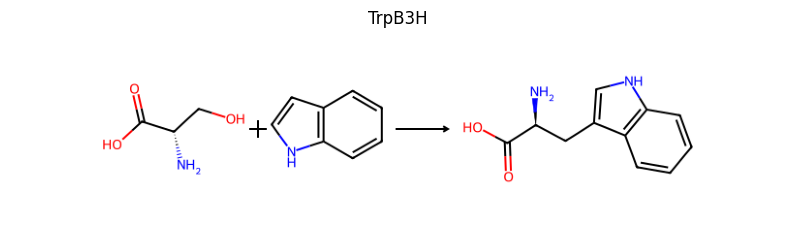

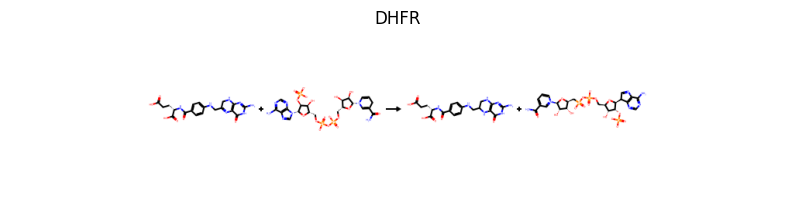

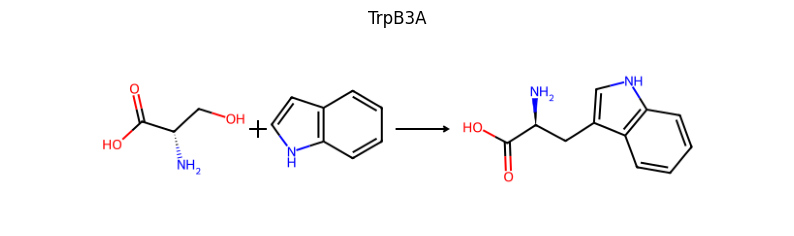

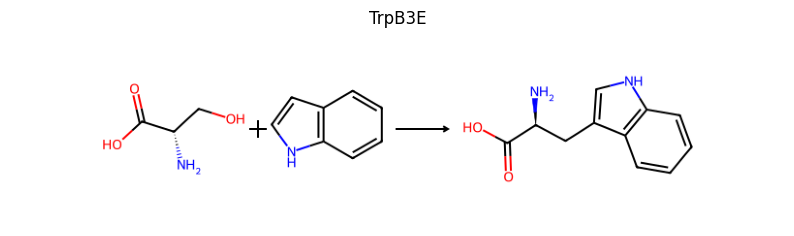

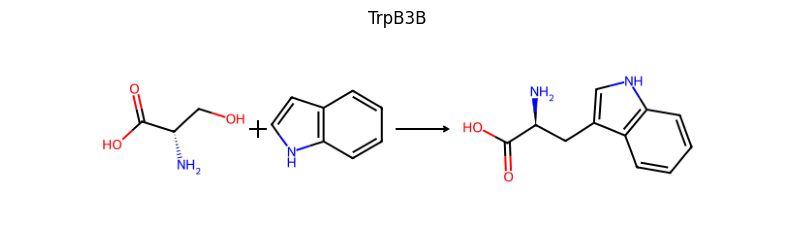

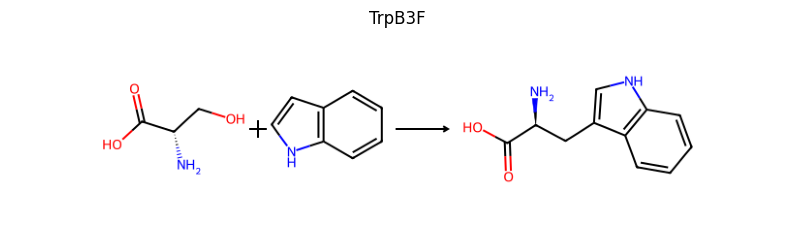

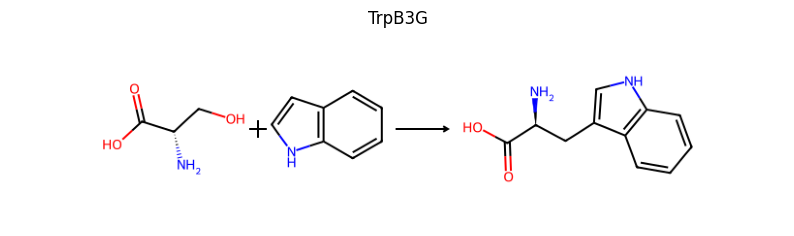

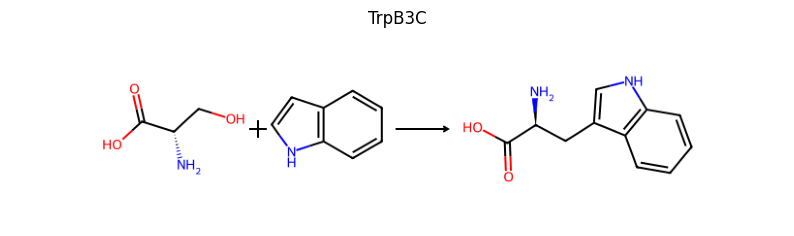

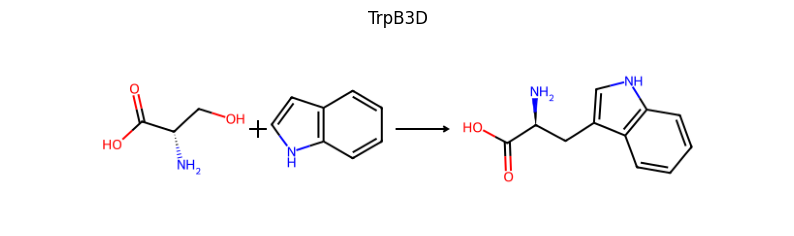

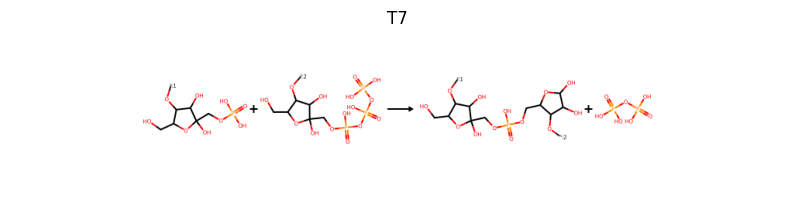

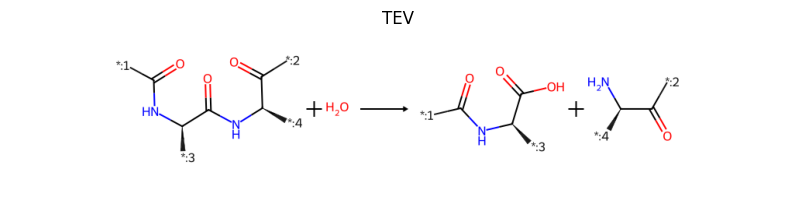

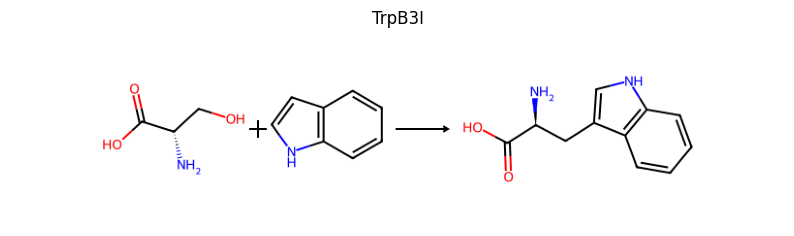

In [12]:
import matplotlib.pyplot as plt

for experiment_id, substrate_smiles, product_smiles in meta_df[['experiment_id', 'substrate_smiles', 'product_smiles']].values:
    rxn_smarts = f"{substrate_smiles}>>{product_smiles}"
    rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts, useSmiles=True)
    print(rxn)
    ideal_final_width = 1000
    w = int(ideal_final_width / (rxn.GetNumReactantTemplates() + rxn.GetNumProductTemplates() + 1))
    
    # this option produces a svg image
    svg_img = Draw.ReactionToImage(rxn, subImgSize=(w, 200), useSVG=True)
    img = Draw.ReactionToImage(rxn)

    plt.figure(figsize=(10, 3))
    plt.title(experiment_id)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

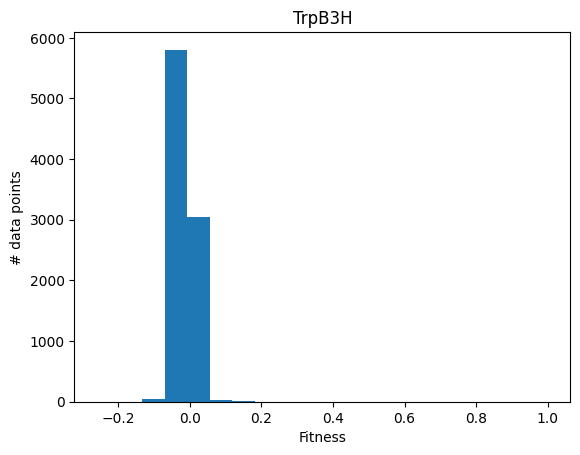

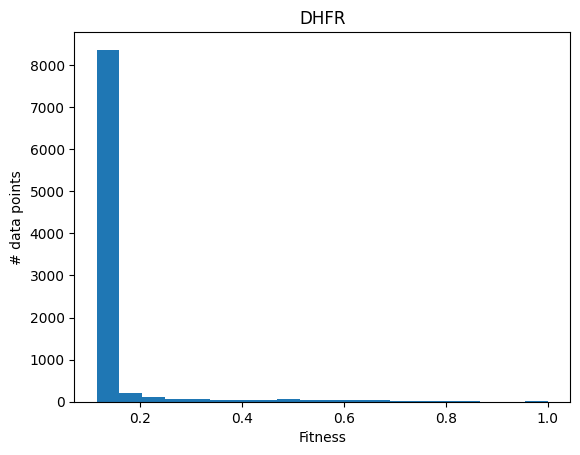

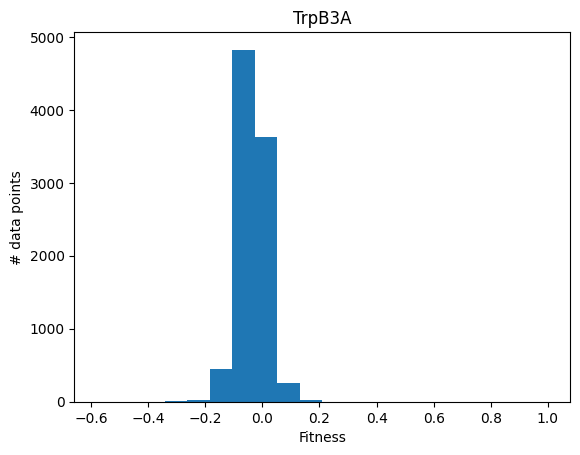

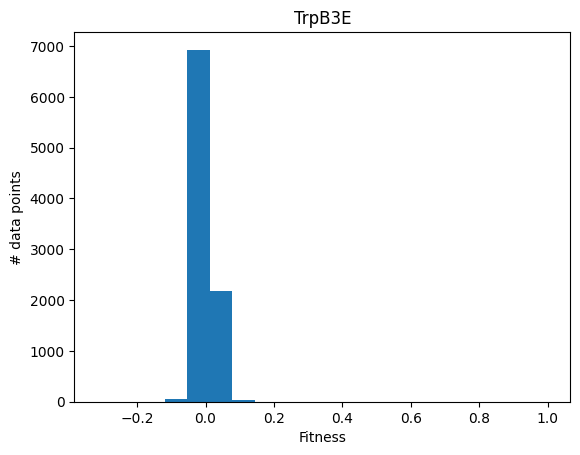

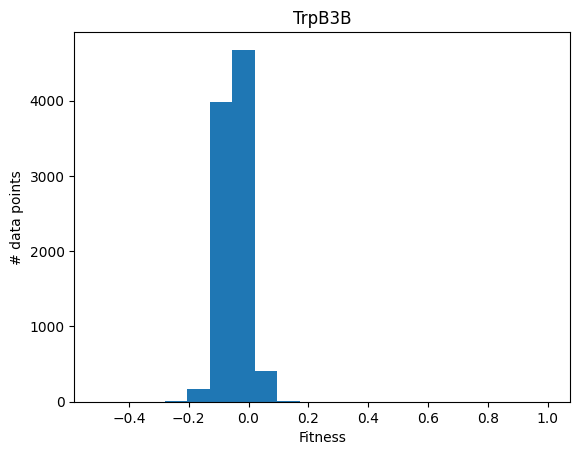

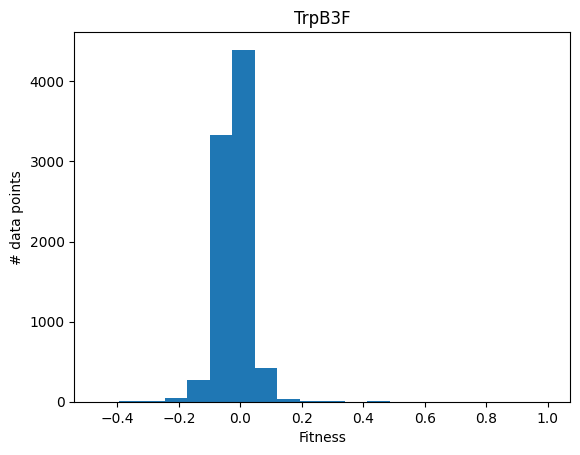

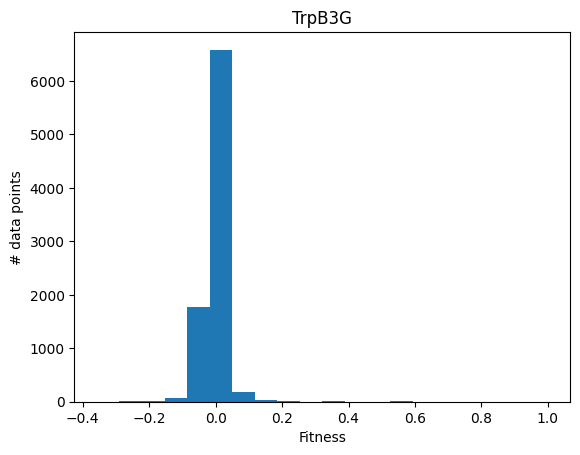

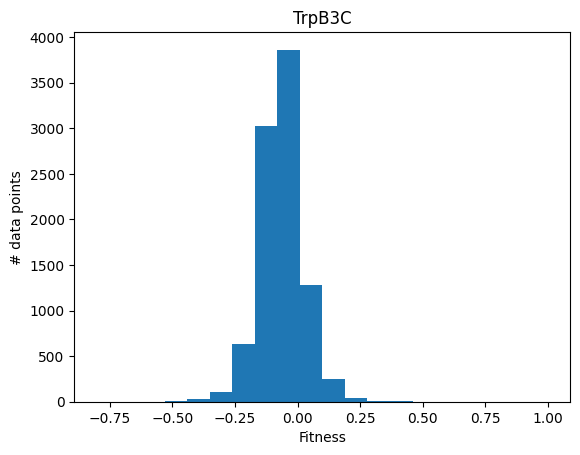

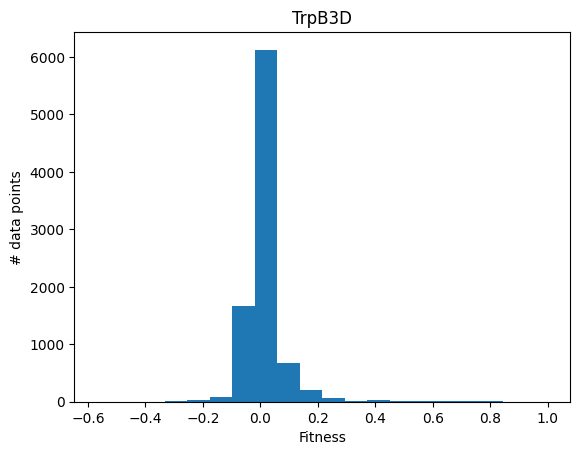

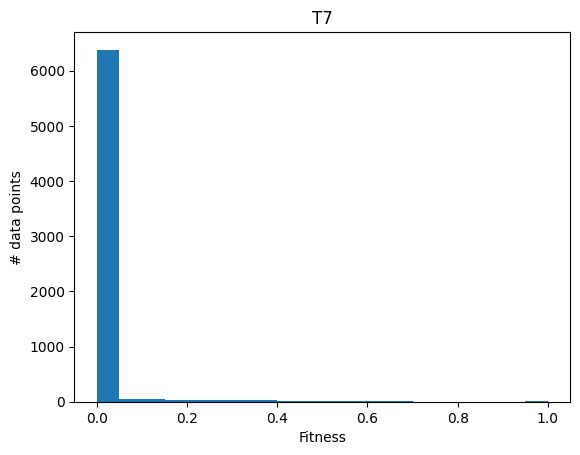

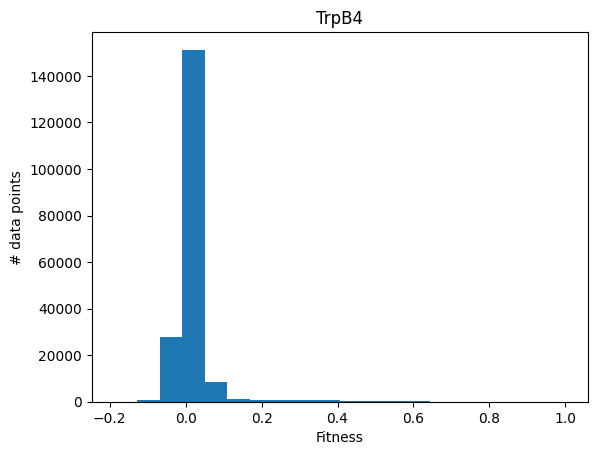

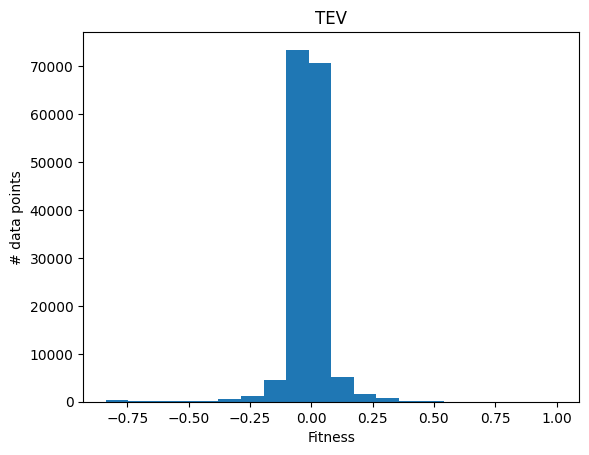

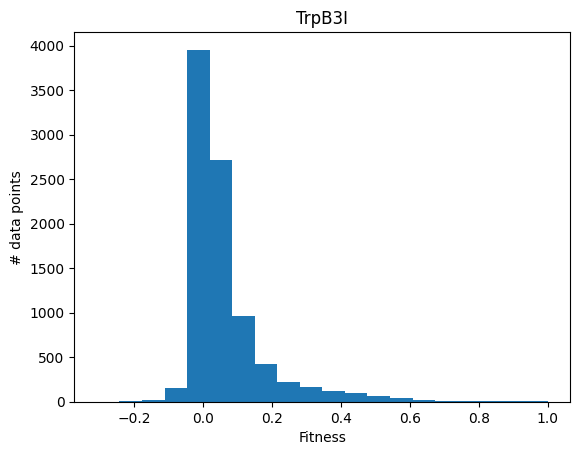

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')
        plt.hist(df['fitness_value'].values, bins=20)
        plt.title(f.replace('_processed.csv', ''))
        plt.xlabel('Fitness')
        plt.ylabel('# data points')
        plt.show()
    except:
        print(f)
